# Olist E-Commerce – EDA & Key Metrics

Connect to the PostgreSQL data warehouse (star schema), run exploratory analysis, and compute business metrics for reporting.

In [10]:
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from config import get_connection_string

engine = create_engine(get_connection_string())
plt.style.use('ggplot')
sns.set_palette('husl')

## 1. Monthly sales trends

In [11]:
query_monthly = """
SELECT
    date_trunc('month', order_date_key)::date AS month,
    SUM(total_item_value) AS revenue,
    COUNT(DISTINCT order_id) AS orders,
    COUNT(*) AS items_sold
FROM dw_dw.fact_order_items
GROUP BY 1
ORDER BY 1;
"""
df_monthly = pd.read_sql(query_monthly, engine)
df_monthly["month"] = pd.to_datetime(df_monthly["month"])
df_monthly.head(10)

,month,revenue,orders,items_sold
0,2016-09-01,354.75,3,6
1,2016-10-01,56808.84,308,363
2,2016-12-01,19.62,1,1
3,2017-01-01,137188.49,789,955
4,2017-02-01,286280.62,1733,1951
5,2017-03-01,432048.59,2641,3000
6,2017-04-01,412422.24,2391,2684
7,2017-05-01,586190.95,3660,4136
8,2017-06-01,502963.04,3217,3583
9,2017-07-01,584971.62,3969,4519


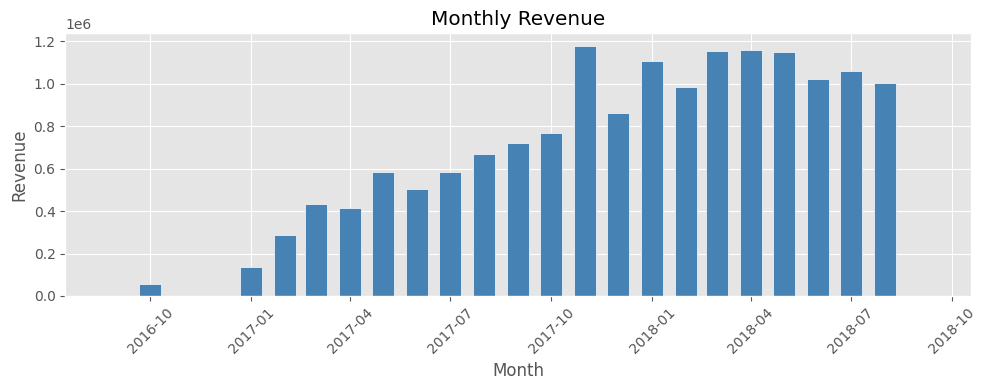

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(df_monthly["month"], df_monthly["revenue"], width=20, color='steelblue', edgecolor='white')
ax.set_title("Monthly Revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Top-selling product categories

In [13]:
query_top = """
SELECT
    COALESCE(p.product_category_name, 'Unknown') AS category,
    SUM(f.total_item_value) AS revenue,
    COUNT(*) AS items_sold
FROM dw_dw.fact_order_items f
LEFT JOIN dw_dw.dim_product p ON p.product_key = f.product_key
GROUP BY 1
ORDER BY revenue DESC
LIMIT 15;
"""
df_top = pd.read_sql(query_top, engine)
df_top

,category,revenue,items_sold
0,beleza_saude,1441248.07,9670
1,relogios_presentes,1305541.61,5991
2,cama_mesa_banho,1241681.72,11115
3,esporte_lazer,1156656.48,8641
4,informatica_acessorios,1059272.40,7827
5,moveis_decoracao,902511.79,8334
6,utilidades_domesticas,778397.77,6964
7,cool_stuff,719329.95,3796
8,automotivo,685384.32,4235
9,ferramentas_jardim,584219.21,4347


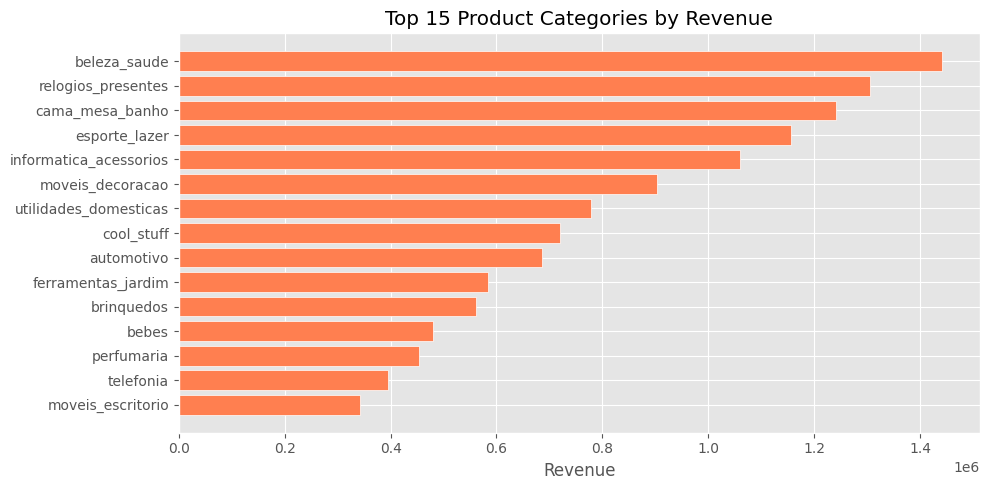

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df_top["category"].iloc[::-1], df_top["revenue"].iloc[::-1], color='coral', edgecolor='white')
ax.set_title("Top 15 Product Categories by Revenue")
ax.set_xlabel("Revenue")
plt.tight_layout()
plt.show()

## 3. Customer segmentation (CLV & tenure)

In [15]:
query_seg = """
SELECT
    tenure_segment,
    COUNT(*) AS customers,
    SUM(total_revenue) AS total_revenue,
    ROUND(AVG(total_revenue), 2) AS avg_revenue_per_customer
FROM dw_dw.dim_customer
GROUP BY tenure_segment
ORDER BY total_revenue DESC;
"""
df_seg = pd.read_sql(query_seg, engine)
df_seg

,tenure_segment,customers,total_revenue,avg_revenue_per_customer
0,Established,59246,9438573.23,159.31
1,Loyal,29974,4790487.93,159.82
2,New,10221,1614492.08,157.96


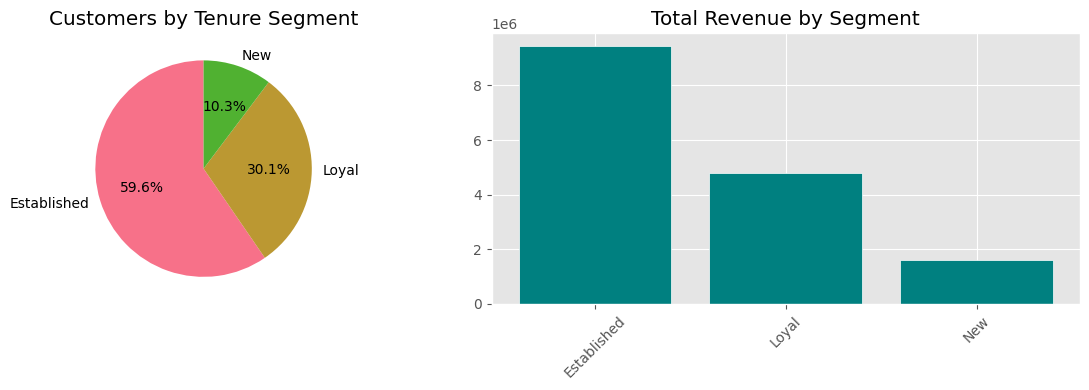

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(df_seg["customers"], labels=df_seg["tenure_segment"], autopct='%1.1f%%', startangle=90)
axes[0].set_title("Customers by Tenure Segment")
axes[1].bar(df_seg["tenure_segment"], df_seg["total_revenue"], color='teal', edgecolor='white')
axes[1].set_title("Total Revenue by Segment")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. Late delivery rate

In [17]:
query_late = """
SELECT
    is_late_delivery,
    COUNT(*) AS items,
    SUM(total_item_value) AS revenue
FROM dw_dw.fact_order_items
WHERE delivery_date_key IS NOT NULL
GROUP BY is_late_delivery;
"""
df_late = pd.read_sql(query_late, engine)
total = df_late["items"].sum()
late_pct = df_late.loc[df_late["is_late_delivery"] == True, "items"].sum() / total * 100 if total else 0
print(f"Late delivery rate (by items): {late_pct:.1f}%")
df_late

Late delivery rate (by items): 6.6%


,is_late_delivery,items,revenue
0,False,102931,14268207.19
1,True,7265,1150936.22
